# One-Dimensional Localized Reaction-Diffusion Front
 We start with the equation
 $$\partial_t \theta = \kappa \partial_x^2 \theta + S(\theta), \qquad \theta \in [0,\theta_h]$$
 where
 $$S(\theta) =
 \begin{cases}
    S_0, \qquad |\theta - \theta_*| < \epsilon/2 \\
    0, \qquad |\theta - \theta_*| \geq \epsilon/2
 \end{cases}$$

 $S_0>0$ represents heating, and $S_0<0$ represents cooling. I will be looking at the cooling case, but this notebook should work for either if you change the value of $S_0$.

In [85]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (7, 4.2)

# Parameters and Characterisitc Scales

We define all parameters and characteristic scales using the cold state $\theta = 0$ as a reference. We define the reaction time as
$$t_\text{react} = \dfrac{\theta_*}{|S_0|}$$
We then have an estimated length and speed of
$$\ell_\text{est} \sim \sqrt{\dfrac{\kappa \theta_*}{|S_0|}}, \qquad v_\text{est} \sim \sqrt{\dfrac{\kappa |S_0|}{\theta_*}}$$

*Note*: There is a separate time, $\epsilon/|S_0|$, that must be resolved numerically. This is the time to cross the active top-hat interval.

In [86]:
# Parameters
S0 = -1.0
kappa = 1.0
theta_h = 1.0
theta_star = 0.5
eps = 0.1

absS0 = abs(S0)

# characteristic scales
t_react = theta_star/absS0
l_est = np.sqrt(kappa*theta_star/absS0)
v_est = np.sqrt(kappa*absS0/theta_h)
t_cross = eps/absS0

print(f"t_react = theta*/|S0|        = {t_react:.4f}")
print(f"l_est   = sqrt(k*theta*/|S0|)= {l_est:.4f}")
print(f"v_est   = sqrt(k*|S0|/theta*)= {v_est:.4f}")
print(f"t_cross = eps/|S0|           = {t_cross:.4f}  (band-crossing time, must be resolved)")

t_react = theta*/|S0|        = 0.5000
l_est   = sqrt(k*theta*/|S0|)= 0.7071
v_est   = sqrt(k*|S0|/theta*)= 1.0000
t_cross = eps/|S0|           = 0.1000  (band-crossing time, must be resolved)


# Numerical Setup
Domain:
$$x \in [-L/2, L/2], \qquad L >> \ell_\text{front}$$
Boundary values:
$$\theta(-L/2,t)=0, \qquad \theta(L/2,t)=\theta_h$$
Initial Condition:
$$\theta(x,0)=\frac{\theta_h}{2}\Big(1+\tanh\frac{x-x_0}{w_0}\Big),$$
which goes smoothly from $\approx 0$ on the left to $\approx \theta_h$ on the right, centered at $x_0$.

In [87]:
# set domain and make the grid
def make_grid(L, N):
    x = np.linspace(-L/2.0, L/2.0, N)
    dx = x[1] - x[0]
    return x, dx

# set initial conditions and boundary conditions
def initial_condition(x, theta_h, x0, w0):
    theta = 0.5*theta_h*(1.0 + np.tanh((x - x0)/w0))
    theta[0]  = 0.0
    theta[-1] = theta_h
    return theta

# Baseline numerical parameters
L   = 40.0
N   = 801     # number of grid points
x0  = 0.0
w0  = 1.0

x, dx = make_grid(L, N)
theta0 = initial_condition(x, theta_h, x0, w0)
print(f"L={L}, N={N}, dx={dx:.5f},  l_est/dx = {l_est/dx:.1f}")

L=40.0, N=801, dx=0.05000,  l_est/dx = 14.1


# The source term, spatial discretization, and the time step

Source term: $S(\theta)$, which is equal to $S_0$ when close to $\theta_*$ and 0 otherwise.

Spatial derivative approximation: we use second-order centered differences (averaging the slope at the beginning and end of an interval) to approximate the second spatial derivative of $\theta$:
$$\partial_x^2\theta \approx \dfrac{\theta_{i+1}-2\theta_i + 2\theta_{i-1}}{\Delta x^2}$$
where the index $i$ is the point where $\theta$ is evaluated. This approximation is valid on the interior nodes; the edge nodes are fixed by the boundary conditions.

Thus, we can rewrite the approximated PDE as
$$f_i(\theta) = \kappa \Big( \dfrac{\theta_{i+1}-2\theta_i + 2\theta_{i-1}}{\Delta x^2} \Big) + S(\theta_i)$$
At the boundary nodes, $f=0$.

In addition, we employ two restrictions on the time step to our explicit scheme:
$$\Delta t \lesssim 0.4\,\dfrac{\Delta x^2}{\kappa} \qquad \text{and} \qquad \Delta t \ll \dfrac{\varepsilon}{|S_0|}$$
so that the simulation does not blow up and so that enough points are sampled in the active region, respectively.

In [88]:
# source term
def source(theta, S0, eps, theta_star):
    return np.where(np.abs(theta-theta_star) < eps/2.0, S0, 0.0)

# rhs of approximated PDE, keep boundary vals at 0
def rhs(theta, kappa, dx, S0, eps, theta_star):
    f = np.zeros_like(theta)
    lap = (theta[2:] - 2.0*theta[1:-1] + theta[:-2]) / dx**2
    f[1:-1] = kappa*lap + source(theta[1:-1], S0, eps, theta_star)
    return f

# choose time step to be smaller of the two bounds
def choose_dt(dx, kappa, eps, S0, cfl=0.4, react_safety=0.2):
    dt_diff  = cfl * dx**2 / kappa
    dt_react = react_safety * eps / abs(S0)
    return min(dt_diff, dt_react)

dt = choose_dt(dx, kappa, eps, S0)
print(f"dt_diff = 0.4*dx^2/kappa = {0.4*dx**2/kappa:.3e}")
print(f"dt_react = 0.2*eps/|S0| = {0.2*eps/abs(S0):.3e}")
print(f"chosen dt = {dt:.3e}  ->  steps to cross band = {(eps/abs(S0))/dt:.0f}")

dt_diff = 0.4*dx^2/kappa = 1.000e-03
dt_react = 0.2*eps/|S0| = 2.000e-02
chosen dt = 1.000e-03  ->  steps to cross band = 100


# RK2 Time Integration

We will use an RK2 integration method to advance through time:
$$k_1=f(\theta^n),\quad \tilde\theta=\theta^n+\Delta t\,k_1,\quad k_2=f(\tilde\theta),\quad
\theta^{n+1}=\theta^n+\tfrac{\Delta t}{2}\,(k_1+k_2).$$

In [89]:
# one RK2 step
def step_rk2(theta, dt, kappa, dx, S0, eps, theta_star):
    k1 = rhs(theta, kappa, dx, S0, eps, theta_star)
    k2 = rhs(theta + dt*k1, kappa, dx, S0, eps, theta_star)
    return theta + 0.5*dt*(k1 + k2)

# Measurements

The front position is defined by $\theta(x_f,t)=\theta_*$, using interpolation between grid points (estimating its position using two neighboring points). Using this, we measure
$$v_f(t)=\dfrac{dx_f}{dt}$$
We also track an interface width:
$$\ell_{10-90} = x(0.9\theta_h)-x(0.1\theta_h)$$
from linear interpolation of the level crossings.

In [90]:
# all x where \theta(x) equals a specific value, found by linear interpolation
def all_crossings(x, theta, level):
    d = theta - level
    idx = np.where(((d[:-1] <= 0.0) & (d[1:] > 0.0)) | 
                   ((d[:-1] >= 0.0) & (d[1:] < 0.0)))[0]
    out = []
    for i in idx:
        denom = d[i] - d[i+1]
        frac = 0.0 if denom == 0.0 else d[i] / denom
        out.append(x[i] + frac * (x[i+1] - x[i]))
    return np.array(out)

def front_position(x, theta, theta_star, prev=None):
    xs = all_crossings(x, theta, theta_star)
    if len(xs) == 0:
        return np.nan
    if prev is None or np.isnan(prev):
        return xs[0]
    return xs[np.argmin(np.abs(xs - prev))]

def width_10_90(x, theta, theta_h):
    lo = all_crossings(x, theta, 0.1*theta_h)
    hi = all_crossings(x, theta, 0.9*theta_h)
    if len(lo) == 0 or len(hi) == 0:
        return np.nan
    return hi[-1] - lo[0]

# Simulation

In [91]:
def simulate(kappa=kappa, S0=S0, eps=eps, theta_star=theta_star, theta_h=theta_h,
             L=L, N=N, x0=x0, w0=w0, t_end=10.0, cfl=0.4, dt=None, n_record=240,
             n_snaps=12):
    x, dx = make_grid(L, N)
    if dt is None:
        dt = choose_dt(dx, kappa, eps, S0, cfl=cfl)
    theta = initial_condition(x, theta_h, x0, w0)

    nsteps = int(round(t_end/dt))
    rec = max(1, nsteps // n_record)          # record
    snap_every = max(1, nsteps // (n_snaps-1))   # snapshot

    ts, xfs, wds = [], [], []
    snaps, snap_t = [], []
    prev = np.nan
    t = 0.0
    for n in range(nsteps + 1):
        if n % rec == 0:
            prev = front_position(x, theta, theta_star, prev)
            ts.append(t); xfs.append(prev); wds.append(width_10_90(x, theta, theta_h))
        if n % snap_every == 0 or n == nsteps:
            snaps.append(theta.copy()); snap_t.append(t)
        theta = step_rk2(theta, dt, kappa, dx, S0, eps, theta_star)
        t += dt

    return dict(x=x, dx=dx, dt=dt, t=np.array(ts), xf=np.array(xfs), wd=np.array(wds),
                theta=theta, snaps=snaps, snap_t=snap_t,
                kappa=kappa, S0=S0, eps=eps, theta_star=theta_star, theta_h=theta_h, L=L)

base = simulate()
print(f"steps used dt={base['dt']:.2e}; recorded {len(base['t'])} frames; "
      f"final xf={base['xf'][-1]:.3f}, final width={base['wd'][-1]:.3f}")
print([f"{t:.3f}" for t in base['snap_t']])

steps used dt=1.00e-03; recorded 244 frames; final xf=8.224, final width=14.864
['0.000', '0.909', '1.818', '2.727', '3.636', '4.545', '5.454', '6.363', '7.272', '8.181', '9.090', '9.999', '10.000']


# Profile evolution of the front

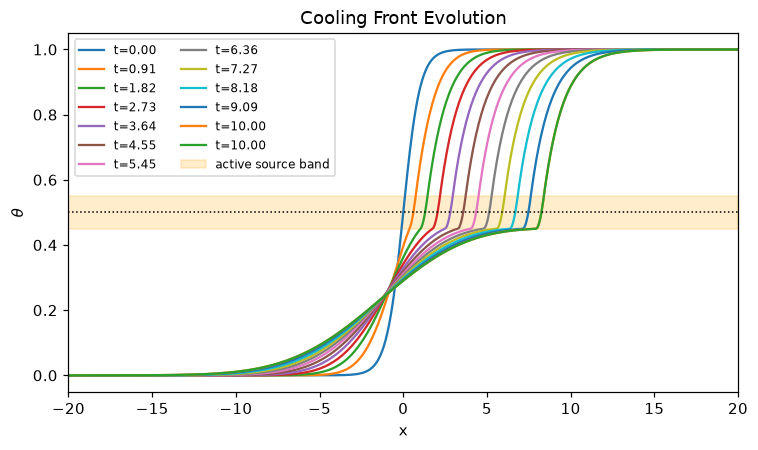

In [92]:
fig, ax = plt.subplots()
for th, tt in zip(base['snaps'], base['snap_t']):
    ax.plot(base['x'], th, label=f"t={tt:.2f}")
ax.axhline(theta_star, ls=':', c='k', lw=1)
ax.axhspan(theta_star-eps/2, theta_star+eps/2, color='orange', alpha=0.2,
           label='active source band')
ax.set_xlabel('x'); ax.set_ylabel(r'$\theta$')
ax.set_xlim(-L/2, L/2); ax.set_title('Cooling Front Evolution')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

# Measured quantities vs time

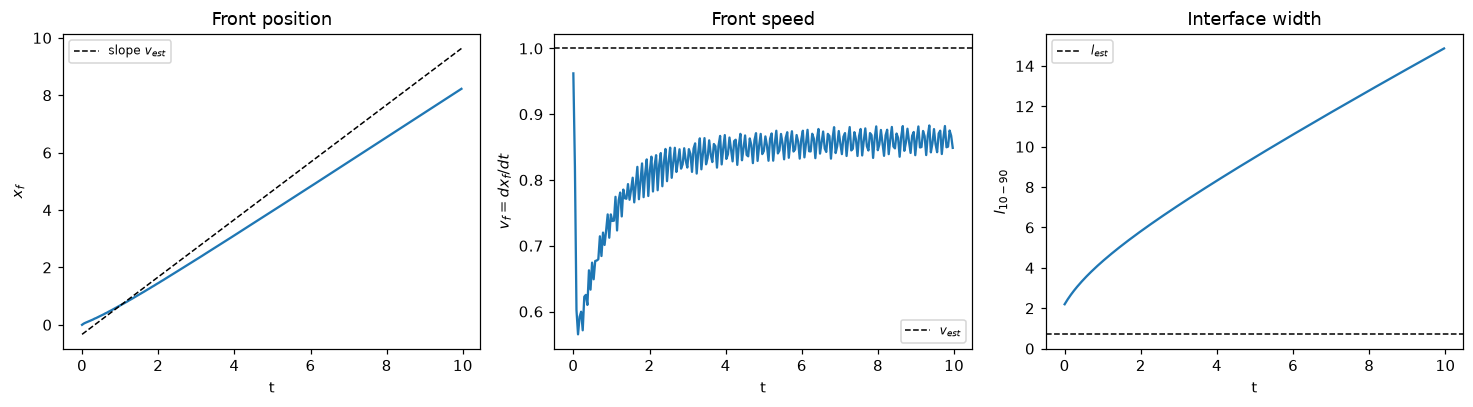

late-time mean speed  ~  0.8563   (v_est = 1.0000)
late-time mean width  ~  11.6630   (l_est = 0.7071)


In [93]:
t = base['t']; xf = base['xf']; wd = base['wd']
vf = np.gradient(xf, t)

fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8))
axs[0].plot(t, xf); axs[0].set_xlabel('t'); axs[0].set_ylabel(r'$x_f$')
axs[0].set_title('Front position')
# reference slope v_est anchored after transient
i0 = np.searchsorted(t, 1.0)
axs[0].plot(t, xf[i0] + v_est*(t - t[i0]), 'k--', lw=1, label=r'slope $v_{est}$')
axs[0].legend(fontsize=8)

axs[1].plot(t, vf); axs[1].axhline(v_est, ls='--', c='k', lw=1, label=r'$v_{est}$')
axs[1].set_xlabel('t'); axs[1].set_ylabel(r'$v_f=dx_f/dt$')
axs[1].set_title('Front speed'); axs[1].legend(fontsize=8)

axs[2].plot(t, wd); axs[2].axhline(l_est, ls='--', c='k', lw=1, label=r'$l_{est}$')
axs[2].set_xlabel('t'); axs[2].set_ylabel(r'$l_{10-90}$')
axs[2].set_title('Interface width'); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"late-time mean speed  ~ {np.nanmean(vf[t>4]): .4f}   (v_est = {v_est:.4f})")
print(f"late-time mean width  ~ {np.nanmean(wd[t>4]): .4f}   (l_est = {l_est:.4f})")

# Test whether speed and width are constant

After the initial transient, we test whether the front is traveling at a constant speed, and whether or not it is diffusive.

Linear  fit: v = 0.8509, b = -0.2730   RMS residual = 1.4256e-02
Sqrt(t) fit: a = 3.8302, b = -4.3291   RMS residual = 2.4503e-01
--> the LINEAR (constant-speed) form fits better in this window.
late-time d(width)/dt ~ 1.0975  (nonzero: width still growing)


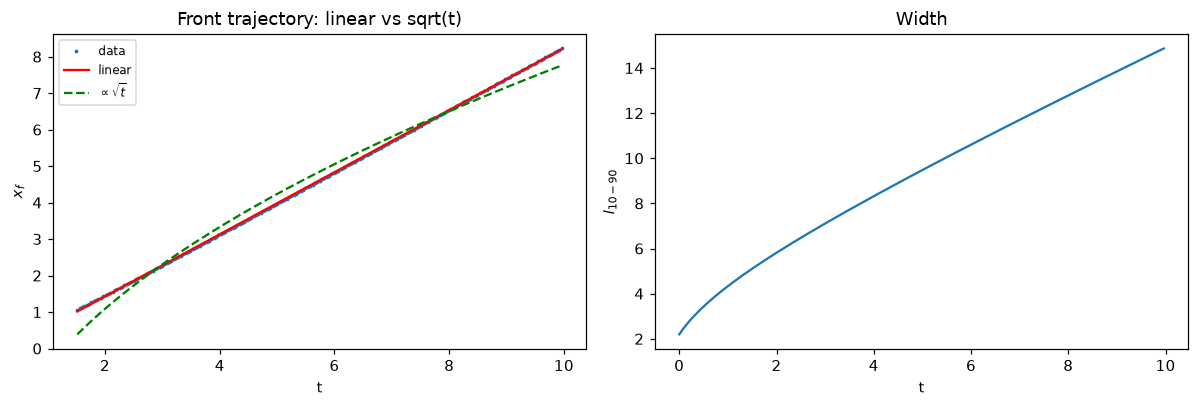

In [94]:
# window: after transient, before boundary
t1 = 1.5
x_cut = 0.55*(L/2)
inwin = (t > t1) & (xf < x_cut) & np.isfinite(xf)
tw, xw = t[inwin], xf[inwin]

# linear fit, xf = v t + b
plin = np.polyfit(tw, xw, 1)
res_lin = xw - np.polyval(plin, tw)
rms_lin = np.sqrt(np.mean(res_lin**2))

# sqrt fit, xf = a sqrt(t) + b
sq = np.sqrt(tw)
psq = np.polyfit(sq, xw, 1)
res_sq = xw - np.polyval(psq, sq)
rms_sq = np.sqrt(np.mean(res_sq**2))

print(f"Linear  fit: v = {plin[0]:.4f}, b = {plin[1]:.4f}   RMS residual = {rms_lin:.4e}")
print(f"Sqrt(t) fit: a = {psq[0]:.4f}, b = {psq[1]:.4f}   RMS residual = {rms_sq:.4e}")
print(f"--> the {'LINEAR (constant-speed)' if rms_lin<rms_sq else 'SQRT(t) (diffusive)'} "
      f"form fits better in this window.")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
axs[0].plot(tw, xw, '.', ms=3, label='data')
axs[0].plot(tw, np.polyval(plin, tw), 'r-', label='linear')
axs[0].plot(tw, np.polyval(psq, sq), 'g--', label=r'$\propto\sqrt{t}$')
axs[0].set_xlabel('t'); axs[0].set_ylabel(r'$x_f$'); axs[0].legend(fontsize=8)
axs[0].set_title('Front trajectory: linear vs sqrt(t)')

axs[1].plot(t, wd); axs[1].set_xlabel('t'); axs[1].set_ylabel(r'$l_{10-90}$')
axs[1].set_title('Width')
g = np.gradient(wd, t)
print(f"late-time d(width)/dt ~ {np.nanmean(g[t>4]):.4f}  "
      f"({'≈0: width saturating' if abs(np.nanmean(g[t>4]))<0.02 else 'nonzero: width still growing'})")
plt.tight_layout(); plt.show()

# Convergence checks

Check convergence with respect to $\Delta x, \Delta t, L, \text{and } w_0$. We compare the late-time mean front speed and late-time mean width.

In [95]:
def late_stats(r, tmin=4.0):
    v = np.gradient(r['xf'], r['t'])
    m = r['t'] > tmin
    return np.nanmean(v[m]), np.nanmean(r['wd'][m])

print('dx:')
for Ni in [401, 801, 1601]:
    r = simulate(N=Ni, t_end=6.0)
    v, w = late_stats(r)
    print(f"  N={Ni:5d}  dx={r['dx']:.4f}  dt={r['dt']:.2e}  late_v={v:.4f}  late_w={w:.4f}")

print('dt:')
for c in [0.4, 0.2, 0.1]:
    r = simulate(N=801, t_end=6.0, cfl=c)
    v, w = late_stats(r)
    print(f"  cfl={c:.2f}  dt={r['dt']:.2e}  late_v={v:.4f}  late_w={w:.4f}")

print('L:')
for Li in [20.0, 40.0, 80.0]:
    Ni = int(round(Li/0.05))
    r = simulate(L=Li, N=Ni, t_end=6.0)
    v, w = late_stats(r)
    print(f"  L={Li:5.0f}  N={Ni:5d}  late_v={v:.4f}  late_w={w:.4f}")

print('w0:')
for wi in [0.5, 1.0, 2.0]:
    r = simulate(w0=wi, t_end=6.0)
    v, w = late_stats(r)
    print(f"  w0={wi:.2f}  late_v={v:.4f}  late_w={w:.4f}")

dx:
  N=  401  dx=0.1000  dt=4.00e-03  late_v=0.8389  late_w=9.4309
  N=  801  dx=0.0500  dt=1.00e-03  late_v=0.8511  late_w=9.4868
  N= 1601  dx=0.0250  dt=2.50e-04  late_v=0.8565  late_w=9.5044
dt:
  cfl=0.40  dt=1.00e-03  late_v=0.8511  late_w=9.4868
  cfl=0.20  dt=5.00e-04  late_v=0.8513  late_w=9.4728
  cfl=0.10  dt=2.50e-04  late_v=0.8514  late_w=9.4871
L:
  L=   20  N=  400  late_v=0.8506  late_w=9.4643
  L=   40  N=  800  late_v=0.8519  late_w=9.4780
  L=   80  N= 1600  late_v=0.8516  late_w=9.4708
w0:
  w0=0.50  late_v=0.8493  late_w=9.1523
  w0=1.00  late_v=0.8511  late_w=9.4868
  w0=2.00  late_v=0.8621  late_w=10.6306


# Compare to characteristic scales

In [96]:
v_meas, w_meas = late_stats(base)
print(f"measured late speed v_f ≈ {v_meas:.4f},   v_est = {v_est:.4f},   ratio = {v_meas/v_est:.2f}")
print(f"measured late width    ≈ {w_meas:.4f},   l_est = {l_est:.4f},   ratio = {w_meas/l_est:.2f}")
print(f"reaction time t_react = {t_react:.3f};  band-crossing time eps/|S0| = {eps/absS0:.3f}")

measured late speed v_f ≈ 0.8563,   v_est = 1.0000,   ratio = 0.86
measured late width    ≈ 11.6630,   l_est = 0.7071,   ratio = 16.49
reaction time t_react = 0.500;  band-crossing time eps/|S0| = 0.100


# Parameter sweeps

In [97]:
def est_v(k, s, ts): return np.sqrt(k*abs(s)/ts)
def est_l(k, s, ts): return np.sqrt(k*ts/abs(s))

def sweep(name, values, **fixed):
    print(f"varying {name}")
    print(f"{name:>8} | {'late_v':>8} {'v_est':>8} | {'late_w':>8} {'l_est':>8}")
    for val in values:
        kw = dict(kappa=kappa, S0=S0, eps=eps, theta_star=theta_star, theta_h=theta_h)
        kw.update(fixed); kw[name] = val
        r = simulate(t_end=6.0, **kw)
        v, w = late_stats(r)
        ve = est_v(kw['kappa'], kw['S0'], kw['theta_star'])
        le = est_l(kw['kappa'], kw['S0'], kw['theta_star'])
        print(f"{val:8.3g} | {v:8.4f} {ve:8.4f} | {w:8.4f} {le:8.4f}")

sweep('kappa',      [0.5, 1.0, 2.0])
sweep('S0',         [-0.5, -1.0, -2.0])
sweep('eps',        [0.05, 0.1, 0.2])
sweep('theta_star', [0.3, 0.5, 0.7])
sweep('theta_h',    [0.8, 1.0, 1.2])

varying kappa
   kappa |   late_v    v_est |   late_w    l_est
     0.5 |   0.6003   1.0000 |   6.9798   0.5000
       1 |   0.8511   1.4142 |   9.4868   0.7071
       2 |   1.2070   2.0000 |  13.0990   1.0000
varying S0
      S0 |   late_v    v_est |   late_w    l_est
    -0.5 |   0.5800   1.0000 |   8.8129   1.0000
      -1 |   0.8511   1.4142 |   9.4868   0.7071
      -2 |   1.2108   2.0000 |  10.7917   0.5000
varying eps
     eps |   late_v    v_est |   late_w    l_est
    0.05 |   0.5804   1.4142 |   8.8310   0.7071
     0.1 |   0.8511   1.4142 |   9.4868   0.7071
     0.2 |   1.1996   1.4142 |  10.6110   0.7071
varying theta_star
theta_star |   late_v    v_est |   late_w    l_est
     0.3 |   0.5912   1.8257 |   7.8810   0.5477
     0.5 |   0.8511   1.4142 |   9.4868   0.7071
     0.7 |   1.4187   1.1952 |  12.2303   0.8367
varying theta_h
 theta_h |   late_v    v_est |   late_w    l_est
     0.8 |   1.4186   1.4142 |  12.0452   0.7071
       1 |   0.8511   1.4142 |   9.4868   0.